In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import os
import seaborn as sns 
from keras.models import Sequential , Model
from keras.layers import Dense,Flatten , Conv2D ,  Reshape , Input , Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
from tensorflow.keras  import layers
from keras.losses import BinaryCrossentropy
from tensorflow.keras.applications import VGG16
import random
import glob
# import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers

print(tf.__version__)


2.21.0


In [111]:
train_pneumonia_dir = '../data/chest_xray/train/PNEUMONIA'
test_pneumonia_dir = '../data/chest_xray/test/PNEUMONIA'
valid_pneumonia_dir = '../data/chest_xray/val/PNEUMONIA'

In [112]:
target_size = (128,128)
batch_size = 32

In [113]:
def plot_multiple_img(img_matrix_list, title_list, ncols, main_title=""):
    fig, myaxes = plt.subplots(figsize=(20, 15), nrows=3, ncols=ncols, squeeze=False)
    fig.suptitle(main_title, fontsize = 30)
    fig.subplots_adjust(wspace=0.3)
    fig.subplots_adjust(hspace=0.3)
    for i, (img, title) in enumerate(zip(img_matrix_list, title_list)):
        myaxes[i // ncols][i % ncols].imshow(img)
        myaxes[i // ncols][i % ncols].set_title(title, fontsize=15)
    plt.show()

In [114]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path)
        if img is not None:
            image_resized = cv2.resize(img, target_size)
            images.append(image_resized)
    return images

#Exploring the data

In [115]:
import glob
train_data = glob.glob('../data/chest_xray/train/**/*.*', recursive=True)
test_data = glob.glob('../data/chest_xray/test/**/*.*', recursive=True)
val_data = glob.glob('../data/chest_xray/val/**/*.*', recursive=True)

print(f"Training Set has: {len(train_data)} images")
print(f"Testing Set has: {len(test_data)} images")
print(f"Validation Set has: {len(val_data)} images")

print(train_data[:5])

Training Set has: 5216 images
Testing Set has: 624 images
Validation Set has: 16 images
['../data/chest_xray/train\\NORMAL\\IM-0115-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0117-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0119-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0122-0001.jpeg', '../data/chest_xray/train\\NORMAL\\IM-0125-0001.jpeg']


In [116]:
DIR = "../data/chest_xray/"
sets = ["train", "test", "val"]
all_pneumonia = []
all_normal = []

for cat in sets:
    path = os.path.join(DIR, cat)
    norm = glob.glob(os.path.join(path, "NORMAL/*.jpeg"))
    pneu = glob.glob(os.path.join(path, "PNEUMONIA/*.jpeg"))
    all_normal.extend(norm)
    all_pneumonia.extend(pneu)

print(f"Total Pneumonia Images: {len(all_pneumonia)}")
print(f"Total Normal Images: {len(all_normal)}")

Total Pneumonia Images: 4273
Total Normal Images: 1583


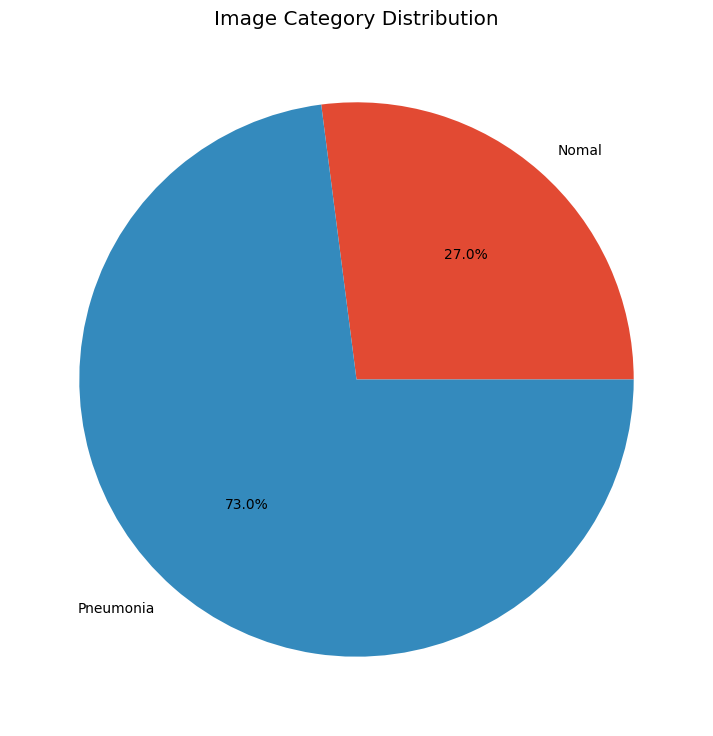

In [117]:
labels = ['Nomal', 'Pneumonia']
targets = [len(all_normal), len(all_pneumonia)]

plt.style.use("ggplot")
plt.figure(figsize=(16, 9))
plt.pie(x=targets, labels=labels, autopct="%1.1f%%")
plt.title("Image Category Distribution")
plt.show()

In [118]:
random.shuffle(all_normal)
random.shuffle(all_pneumonia)
images = all_normal[:50] + all_pneumonia[:50]

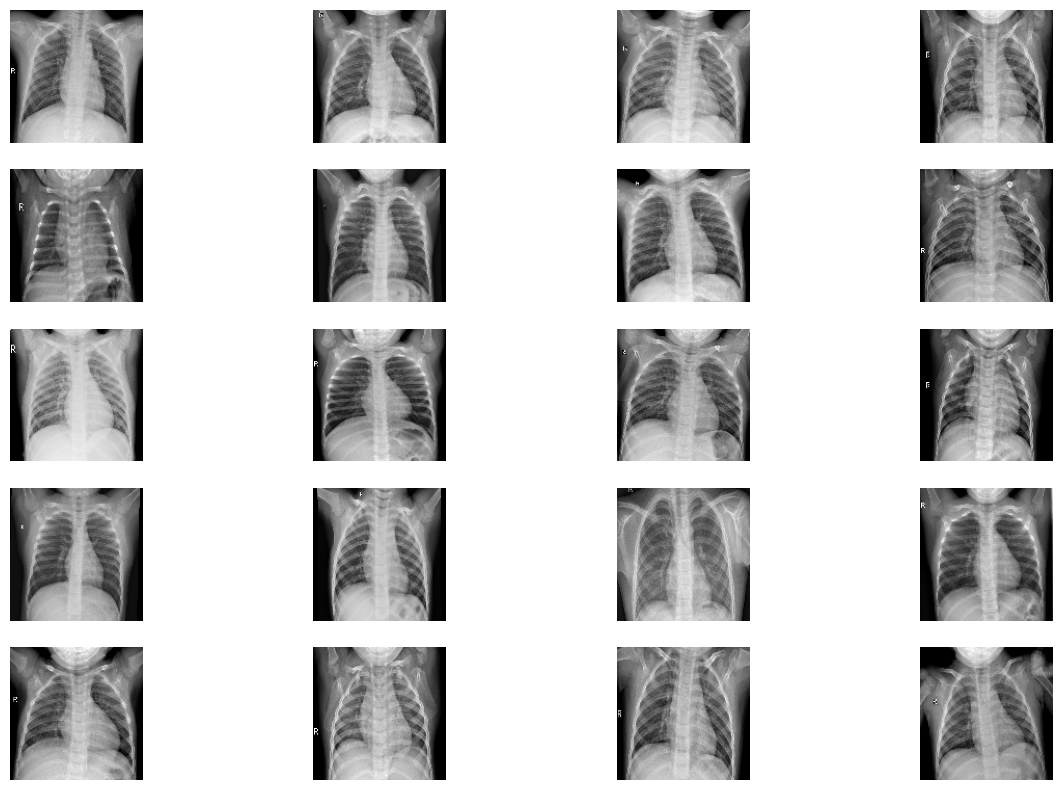

In [119]:
fig=plt.figure(figsize=(15, 10))
columns = 4; rows = 5
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (128, 128))
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
    plt.axis(False)

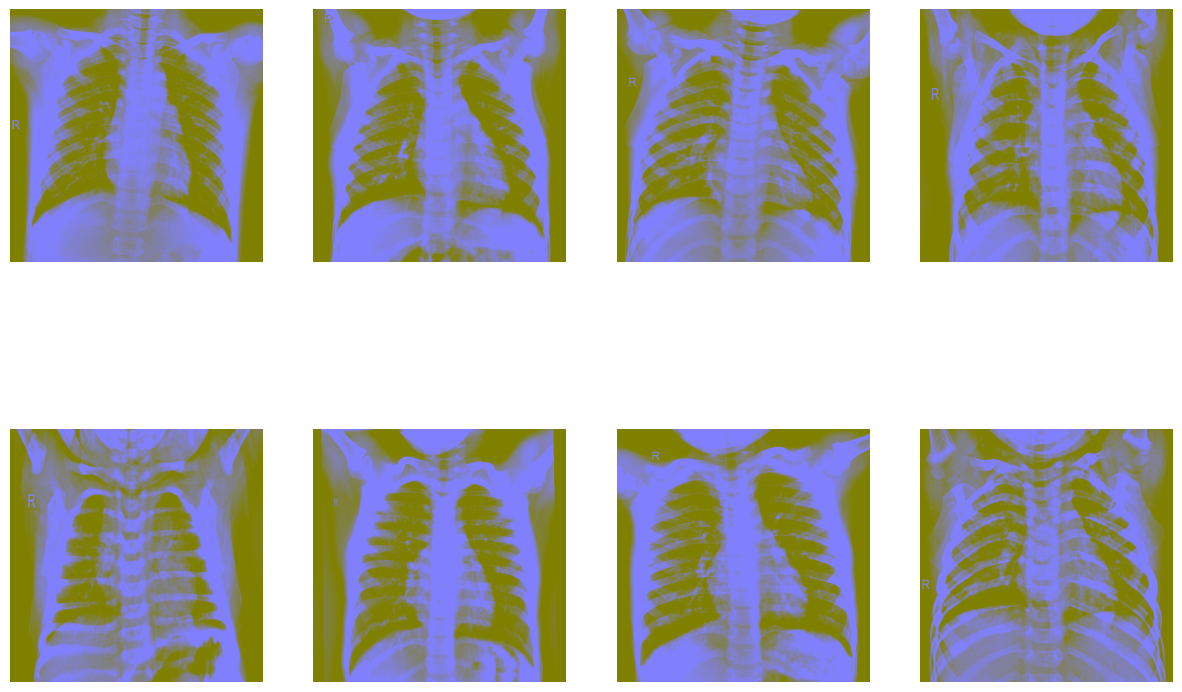

In [120]:
fig=plt.figure(figsize=(15, 10))
columns = 4; rows = 2
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img = cv2.addWeighted (img, 4, cv2.GaussianBlur(img, (0,0), 512/10), -4, 128)
    fig.add_subplot(rows, columns, i)
    plt.imshow(img)
    plt.axis(False)

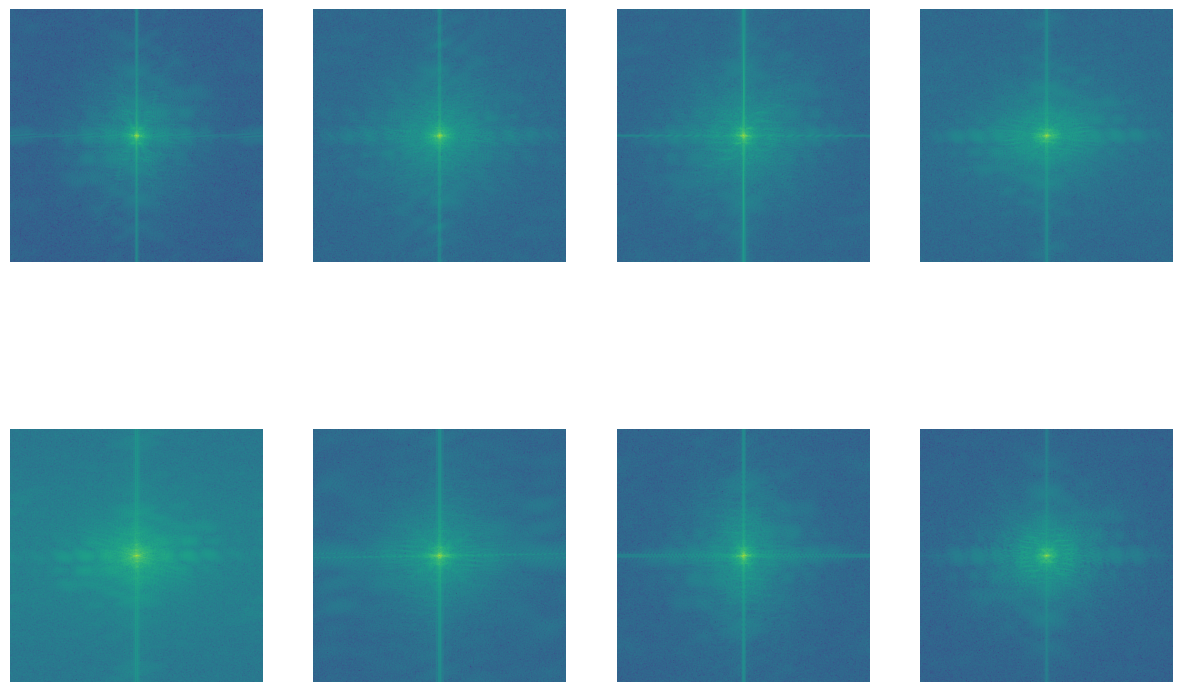

In [121]:
fig=plt.figure(figsize=(15, 10))
columns = 4; rows = 2
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20*np.log(np.abs(fshift))
    fig.add_subplot(rows, columns, i)
    plt.imshow(magnitude_spectrum)
    plt.axis(False)

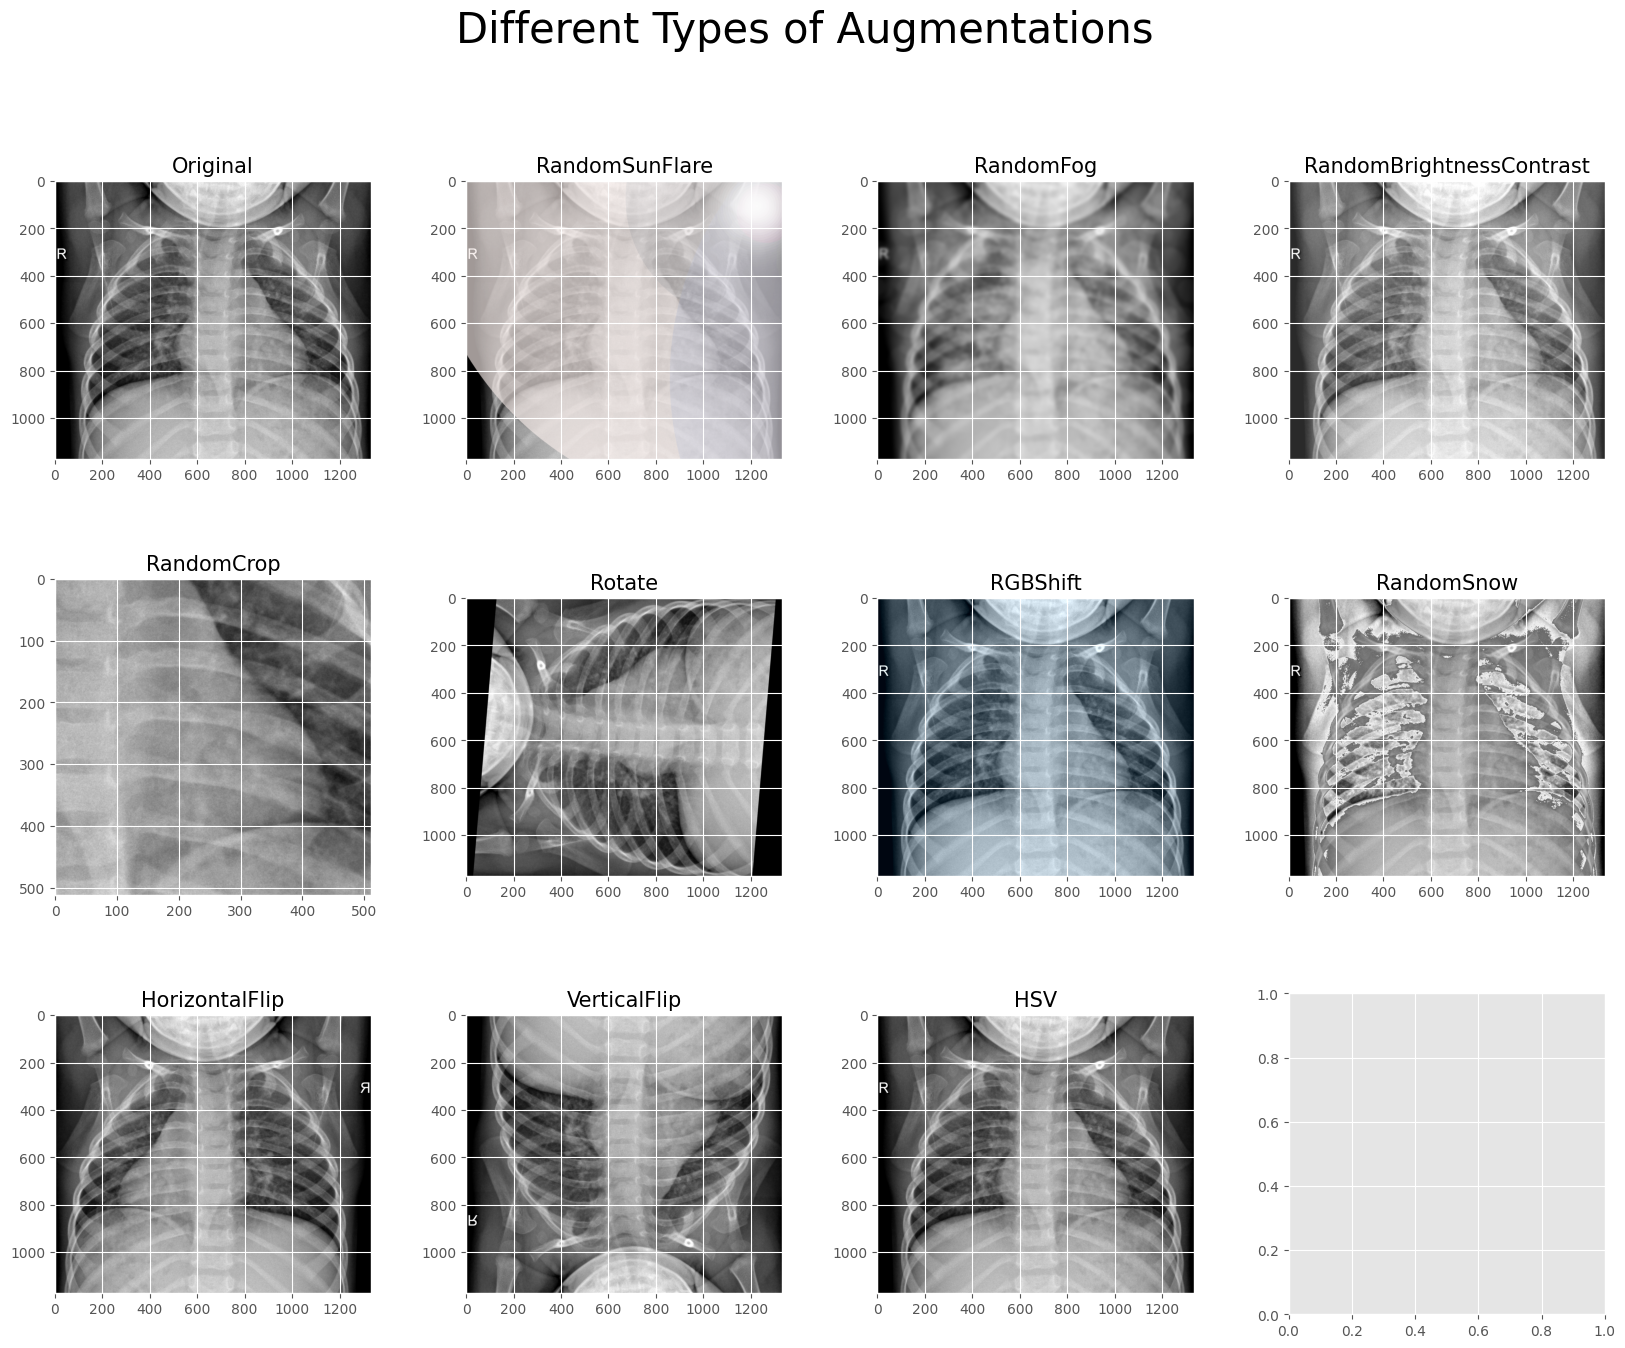

In [122]:
import albumentations as  A

chosen_image = cv2.imread(images[25])

albumentation_list = [
    A.RandomSunFlare(p=1), 
    A.RandomFog(p=1), 
    A.RandomBrightnessContrast(p=1),  # Corrected
    A.RandomCrop(p=1, height=512, width=512), 
    A.Rotate(p=1, limit=90),
    A.RGBShift(p=1), 
    A.RandomSnow(p=1),
    A.HorizontalFlip(p=1), 
    A.VerticalFlip(p=1), 
    A.HueSaturationValue(p=1, hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=50)
]

img_matrix_list = []
bboxes_list = []
for aug_type in albumentation_list:
    img = aug_type(image=chosen_image)['image']
    img_matrix_list.append(img)

# Include the original image at the start of the list
img_matrix_list.insert(0, chosen_image)

# Updated titles list
titles_list = [
    "Original", "RandomSunFlare", "RandomFog", "RandomBrightnessContrast", 
    "RandomCrop", "Rotate", "RGBShift", "RandomSnow", 
    "HorizontalFlip", "VerticalFlip", "HSV"
]

# Assuming plot_multiple_img is a function to display multiple images
plot_multiple_img(img_matrix_list, titles_list, ncols=4, main_title="Different Types of Augmentations")

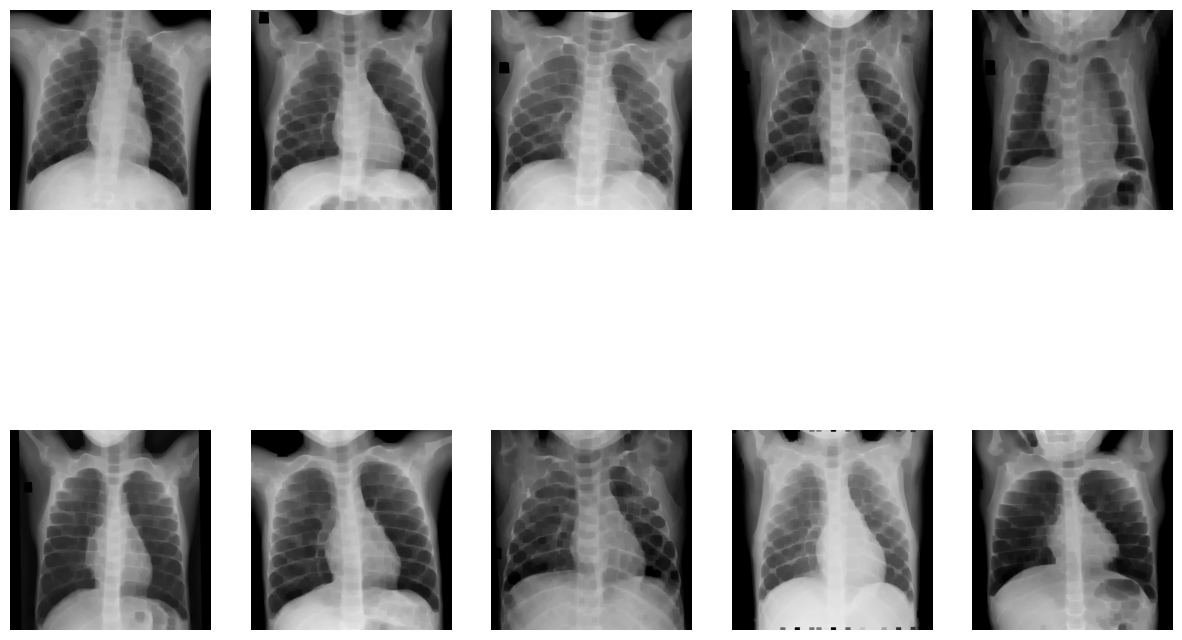

In [123]:
fig=plt.figure(figsize=(15, 10))
columns = 5; rows = 2
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    kernel = np.ones((5, 5), np.uint8)
    img_erosion = cv2.erode(img, kernel, iterations=3)
    fig.add_subplot(rows, columns, i)
    plt.imshow(img_erosion)
    plt.axis(False)

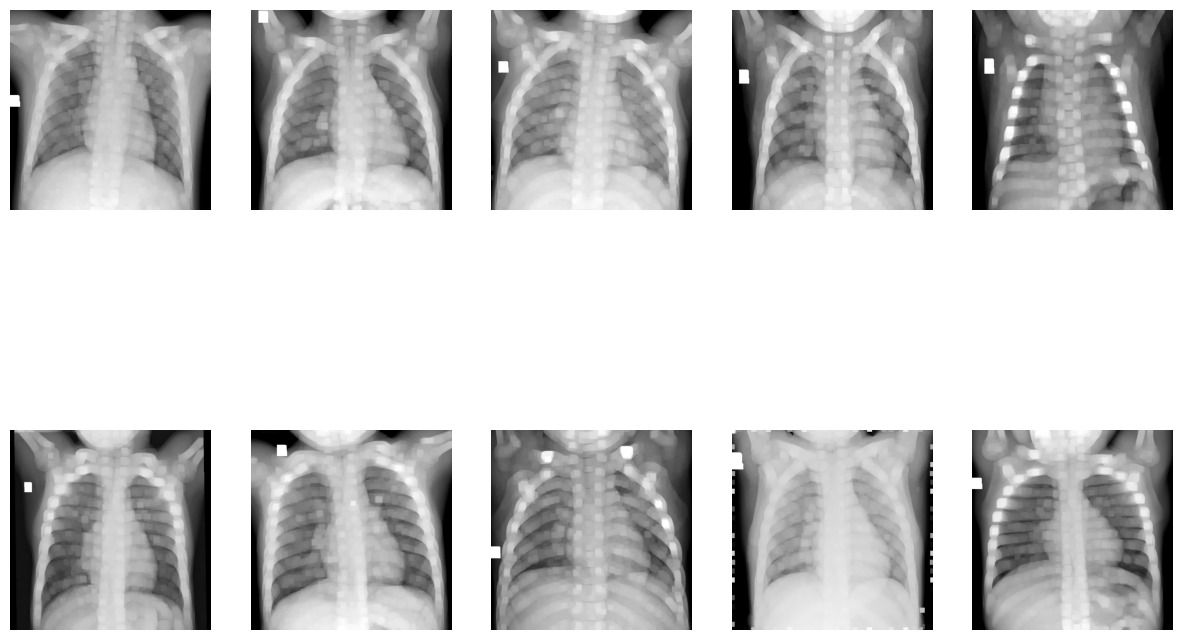

In [124]:
fig=plt.figure(figsize=(15, 10))
columns = 5; rows = 2
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    kernel = np.ones((5, 5), np.uint8)
    img_erosion = cv2.dilate(img, kernel, iterations=3)
    fig.add_subplot(rows, columns, i)
    plt.imshow(img_erosion)
    plt.axis(False)

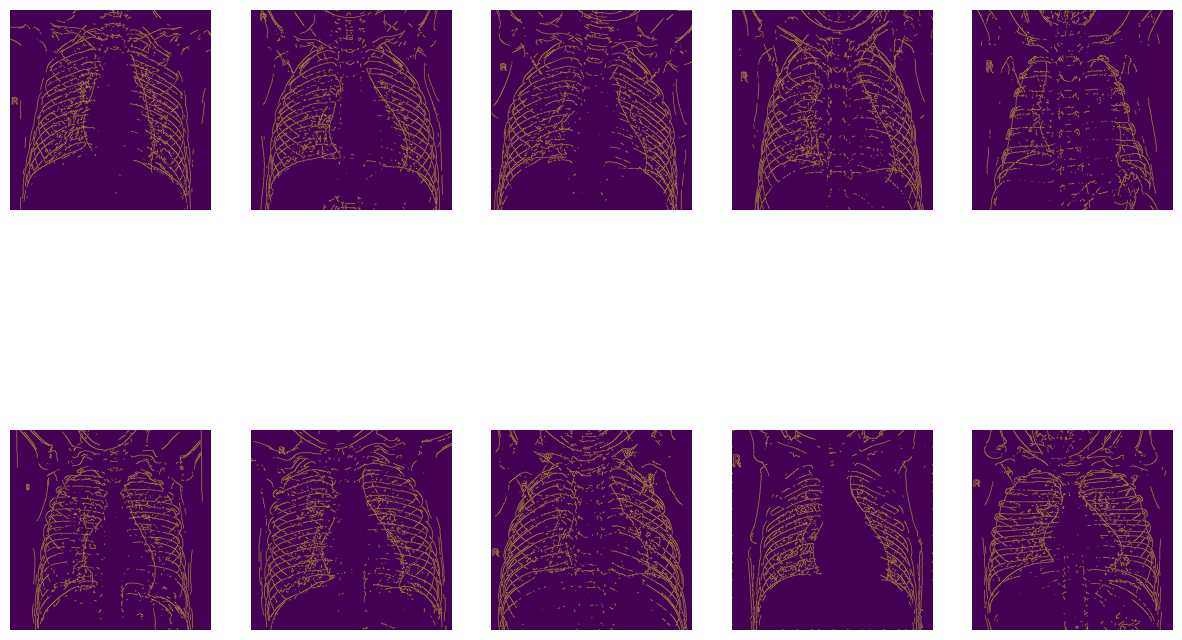

In [125]:
fig=plt.figure(figsize=(15, 10))
columns = 5; rows = 2
for i in range(1, columns*rows +1):
    img = cv2.imread(images[i])
    img = cv2.resize(img, (512, 512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(img, 80, 100)
    fig.add_subplot(rows, columns, i)
    plt.imshow(edges)
    plt.axis(False)

In [126]:
train_images = load_images_from_folder(train_pneumonia_dir)
test_images = load_images_from_folder(test_pneumonia_dir)
valid_images = load_images_from_folder(valid_pneumonia_dir)

X = train_images + test_images + valid_images

X = np.array(X)

X = (X - 127.5) / 127.5

print(f"Loaded {len(X)} images, each resized to {target_size}.")

Loaded 4273 images, each resized to (128, 128).


In [129]:
X.shape

(4273, 128, 128, 3)

In [130]:
dataset = tf.data.Dataset.from_tensor_slices(X).shuffle(buffer_size=1000).batch(batch_size)


In [132]:
generator = tf.keras.Sequential()

# First layer: Dense + BatchNorm + LeakyReLU, input shape is the noise vector (100,)
generator.add(layers.Dense(16 * 16 * 256, use_bias=False, input_shape=(100,)))
generator.add(layers.BatchNormalization())
generator.add(layers.LeakyReLU())

# Reshape the output to (16, 16, 256)
generator.add(layers.Reshape((16, 16, 256)))

# Layer 2: Upsample to (32, 32, 128) with Conv2DTranspose
generator.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
generator.add(layers.BatchNormalization())
generator.add(layers.LeakyReLU())

# Layer 3: Upsample to (64, 64, 64) with Conv2DTranspose
generator.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
generator.add(layers.BatchNormalization())
generator.add(layers.LeakyReLU())

# Layer 4: Upsample to (128, 128, 32) with Conv2DTranspose
generator.add(layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
generator.add(layers.BatchNormalization())
generator.add(layers.LeakyReLU())

# Final output layer: Conv2DTranspose to get the 128x128x3 RGB image
generator.add(layers.Conv2DTranspose(3, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh'))

# Model summary
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 65536)          │     6,553,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65536)          │       262,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 32)   │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 3)    │         2,400 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,894,240 (30.11 MB)

 Trainable params: 7,762,720 (29.61 MB)

 Non-trainable params: 131,520 (513.75 KB)

In [133]:
discriminator =  tf.keras.Sequential()
# First layer: Input shape (128, 128, 3) -> Downsample to (64, 64, 64)
discriminator.add(layers.Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=(128, 128, 3), use_bias=False))
discriminator.add(layers.LeakyReLU(0.2))

# Second layer: Downsample to (32, 32, 128)
discriminator.add(layers.Conv2D(128, kernel_size=4, strides=2, padding='same', use_bias=False))
discriminator.add(layers.BatchNormalization())
discriminator.add(layers.LeakyReLU(0.2))

# Third layer: Downsample to (16, 16, 256)
discriminator.add(layers.Conv2D(256, kernel_size=4, strides=2, padding='same', use_bias=False))
discriminator.add(layers.BatchNormalization())
discriminator.add(layers.LeakyReLU(0.2))

# Fourth layer: Downsample to (8, 8, 512)
discriminator.add(layers.Conv2D(512, kernel_size=4, strides=2, padding='same', use_bias=False))
discriminator.add(layers.BatchNormalization())
discriminator.add(layers.LeakyReLU(0.2))

# Fifth layer: Downsample to (4, 4, 512) and then to a single value
discriminator.add(layers.Conv2D(1, kernel_size=4, strides=1, padding='valid', use_bias=False))
discriminator.add(layers.Flatten())  # Flatten to a single output
discriminator.add(layers.Activation('sigmoid'))  # Binary classification (real or fake)

# Model summary
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 1)        │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 25)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,767,360 (10.56 MB)

 Trainable params: 2,765,568 (10.55 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [154]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
def train_step(images, batch_size):
    noise = tf.random.normal([batch_size, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [157]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [158]:
def train(dataset, epochs, batch_size):
    """
    Trains the GAN model for a specified number of epochs.
    
    Parameters:
        dataset (tf.data.Dataset): The dataset containing real images, usually preprocessed and batched.
        epochs (int): Number of epochs to train the model.
        batch_size (int): The size of batches used during training.
    """
    g_losses,d_losses = [],[]
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch, batch_size)
            g_losses.append(gen_loss)
            d_losses.append(disc_loss)

        
        print(f"Generator Loss: {gen_loss}, Discriminator Loss: {disc_loss}")
        
        
        if (epoch + 1) % 50 == 0:  # Save model every 50 epochs
            generator.save(f'generator_epoch_{epoch+1}.h5')
            discriminator.save(f'discriminator_epoch_{epoch+1}.h5')
            
    return g_losses,d_losses

In [160]:
g_losses,d_losses = train(dataset, epochs=1, batch_size=2)


Epoch 1/1
gen_loss: 6.441073894500732, disc_loss: 0.0059340656735002995
grad gen: [[ 6.4490509e-05  1.2633219e-04  7.2690385e-04 ... -1.1425829e-03
   1.3825232e-03  7.5130947e-03]
 [-2.5891018e-04 -5.0718774e-04 -2.9183018e-03 ...  4.5871241e-03
  -5.5504162e-03 -3.0162822e-02]
 [ 2.2795345e-04  4.4654607e-04  2.5693737e-03 ... -4.0386613e-03
   4.8867776e-03  2.6556389e-02]
 ...
 [-2.0883517e-05 -4.0909377e-05 -2.3538824e-04 ...  3.6999444e-04
  -4.4769284e-04 -2.4329131e-03]
 [ 2.0945485e-05  4.1031057e-05  2.3608663e-04 ... -3.7109142e-04
   4.4902097e-04  2.4401306e-03]
 [-1.3072182e-04 -2.5607570e-04 -1.4734288e-03 ...  2.3160041e-03
  -2.8023636e-03 -1.5228984e-02]]
grad disc: [[[[-8.3483267e-04 -4.1420825e-04  6.2764459e-04 ... -3.2682393e-03
     7.4974238e-04 -2.7713622e-03]
   [-3.6467568e-03 -2.7839937e-03  2.7360593e-03 ... -3.8090528e-03
     2.9116767e-03  1.8414143e-03]
   [-1.9407084e-03 -4.4265203e-03  1.0567151e-03 ... -2.1942344e-03
     3.1101129e-03  1.6802738e-03

In [162]:
print("Generator trainable vars:", len(generator.trainable_variables))
print("Discriminator trainable vars:", len(discriminator.trainable_variables))

Generator trainable vars: 13
Discriminator trainable vars: 11


In [163]:
test_batch = next(iter(dataset))
print("Test batch shape:", test_batch.shape)
try:
    result = train_step(test_batch, batch_size)
    print("train_step result:", result)
except Exception as e:
    print("Error in train_step:", e)

Test batch shape: (32, 128, 128, 3)
gen_loss: 7.5996623039245605, disc_loss: 0.0032804212532937527
grad gen: [[-7.1640412e-04  8.4158563e-04  4.8096143e-04 ...  2.2888076e-04
   9.3461835e-04 -2.0627856e-04]
 [ 2.0839635e-03  9.3886926e-04  1.9915795e-03 ...  3.7752913e-04
   2.2152028e-04  2.4768163e-04]
 [ 2.1913368e-04 -5.3954784e-05  1.2847278e-03 ...  6.2674930e-04
   6.4056425e-04  5.2964565e-04]
 ...
 [ 1.2192017e-03 -1.3795248e-04  1.1710223e-04 ... -7.1399962e-04
  -1.0600694e-03 -9.3676856e-05]
 [-3.8295332e-04 -1.9119951e-03 -1.3477568e-03 ... -1.0062715e-03
  -2.8122945e-03 -1.0991017e-03]
 [-2.1095324e-04  1.4527065e-03 -8.7549997e-05 ... -8.5027816e-05
  -6.7140954e-04 -6.3577347e-04]]
grad disc: [[[[-2.1041778e-05  2.1356158e-03 -1.6045802e-03 ...  1.1691260e-03
    -5.4498669e-06 -2.3691393e-03]
   [ 7.8036694e-04 -8.8244095e-05 -6.9488829e-04 ...  1.2545130e-03
    -1.6137946e-03 -1.2405796e-03]
   [ 1.4628061e-03  1.5913998e-04  2.3400390e-03 ...  9.1849128e-04
     2